In [1]:
# 02.09.2026 - 20260902d.ipynb: CZY OSCYLACJE ROCZNIKA SA SEJSMICZNE CZY DETEKCYJNE.
#
# JEDEN watek. Pytanie postawione przez Macka po notebooku c: na koncu krzywej
# rocznego tempa katalogu (mniej wiecej od 2005) widac wyrazne wahania, ktorych
# we wczesnym okresie nie widac. Hipoteza Macka: te wahania sa TAM CALY CZAS, a
# wczesniej sa zagluszane przez wzrost zageszczenia sieci sejsmometrow. Jesli
# tak, to era 2008 moglaby byc jedyna "normalna", a wszystkie wczesniejsze
# artefaktem zageszczenia. Zaproponowane przez niego narzedzie: sprawdzic, czy
# katalogi o roznych progach magnitudy maja te same oscylacje - z zastrzezeniem
# (tez jego), ze kazdy prog staje sie kompletny w innym momencie.
#
# TO JEST NAJWAZNIEJSZE PYTANIE, JAKIE ZOSTALO. Dotychczasowe notebooki
# pokazaly, ze struktura z Fig.4 nie potrzebuje niczego poza rocznikiem, i ze
# rocznik bez oscylacji wystarcza dla trzech z pieciu er. Zostaje wiec pytanie o
# sam rocznik: czy jego wieloletnia zmiennosc jest detekcyjna, czy fizyczna. Na
# to pytanie mozna odpowiedziec BEZ CALEJ MASZYNERII ARTYKULU - bez okna 3350
# dni, bez skanu po t0, bez kary za proby. I tak wlasnie robi ten notebook.
#
# UCZCIWE ZASTRZEZENIE O KOLEJNOSCI (wazne przy czytaniu wynikow): wersja
# eksploracyjna tego rachunku byla zrobiona w konsoli PRZED napisaniem
# notebooka, wiec ten test NIE jest slepy. Konsekwencje wyciagniete z tego
# faktu: (1) prog glowny jest wybierany kryterium OBIEKTYWNYM (diagnostyka
# kompletnosci), a nie po p-wartosci; (2) wszystkie pozostale progi sa
# raportowane jako eksploracyjne, z jawna kara za wielokrotne proby; (3) jest
# walidacja na polowkach okresu, ktorej w konsoli nie bylo. Wynik tego notebooka
# nalezy traktowac jako HIPOTEZE DO POTWIERDZENIA na niezaleznych danych, a nie
# jako pomiar.
#
# METODA - trzy kroki, kazdy odpowiada na osobne pytanie:
#
#  (1) DIAGNOSTYKA KOMPLETNOSCI. Dla katalogu kompletnego powyzej progu M1 i
#      stabilnego wykladnika Gutenberga-Richtera stosunek N(>=M1)/N(>=M2) jest
#      STALY w czasie i rowny 10^(b*(M2-M1)). Dryf tego stosunku wstecz w czasie
#      oznacza, ze nizszy prog przestaje byc kompletny. To jest wprost odpowiedz
#      na zastrzezenie Macka o "czasie, od kiedy mozemy mowic o kompletnosci" -
#      i to ona wybiera prog glowny do dalszych testow.
#
#  (2) ODTRENDOWANIE TRZEMA NIEZALEZNYMI METODAMI. Reszta = licznik podzielony
#      przez dopasowany trend. Metody sa trzy, bo kazda ma inne obciazenie:
#        - izotoniczna (jak w notebooku c): tam, gdzie szereg szybko rosnie,
#          monotoniczne dopasowanie moze wiernie podazac za wahaniami i je ZJADA,
#          wiec wczesna reszta jest zanizona Z KONSTRUKCJI. To jest dokladnie
#          zarzut Macka i trzeba go traktowac powaznie.
#        - wielomian 3. stopnia: nie potrafi odwzorowac zadnej oscylacji
#          ~11-letniej, wiec jej nie zje; za to nie potrafi tez odwzorowac
#          ostrego skoku z 1973 roku.
#        - mediana biegnaca w oknie 21 lat: dosc dluga, zeby nie wchlonac cyklu
#          ~11-letniego, i odporna na skoki.
#      Wniosek wolno wyciagac tylko z tego, co wychodzi we WSZYSTKICH TRZECH.
#
#  (3) TEST WPROST: czy reszta koreluje z cyklem slonecznym (liczba plam) i z
#      samym strumieniem promieniowania kosmicznego (Moskwa)? Ze skanem po lagu,
#      z DWOMA rozkladami zerowymi i z walidacja na polowkach okresu.
#
# ROZKLADY ZEROWE - dlaczego dwa. Reszta jest silnie autoskorelowana, wiec
# zwykly test istotnosci dla korelacji jest tu bezwartosciowy. Uzywamy:
#   - przesuniec cyklicznych reszty (zachowuje jej autokorelacje dokladnie, ale
#     przy 60 latach i drajwerze ~11-letnim daje tylko okolo 5-6 istotnie
#     roznych ustawien, wiec jest OPTYMISTYCZNY);
#   - randomizacji faz Fouriera (zachowuje widmo mocy, czyli autokorelacje, a
#     niszczy faze; daje znacznie wiecej niezaleznych realizacji).
# Raportujemy obie. Jesli sie roznia, wiazaca jest ta ostrozniejsza.
#
# REGULY ODCZYTU - USTALONE PRZED URUCHOMIENIEM NOTEBOOKA:
#   Dla pytania "sejsmiczne czy detekcyjne":
#     A. reszta przy niskim progu koreluje mocno (r > 0,7) z reszta progow
#        kompletnych w OBU okresach -> oscylacje sa sejsmiczne przez caly czas;
#     B. korelacja slaba wczesnie, mocna pozno -> katalog niskiego progu staje
#        sie uzyteczny dopiero pozno, czyli hipoteza Macka o erze 2008 jako
#        najmniej skazonej;
#     C. korelacja slaba w obu okresach -> oscylacje niskiego progu sa
#        wlasnoscia katalogu, nie Ziemi.
#   Dla pytania o cykl sloneczny (prog glowny, po karze za wielokrotne proby):
#     p < 0,01  -> sygnal wart osobnego, potwierdzajacego badania;
#     0,01-0,1  -> przeslanka, nie wynik; wymaga niezaleznych danych;
#     p >= 0,1  -> brak podstaw do mowienia o zwiazku rocznika z cyklem.
#
# KOSZT: sekundy. Zadnych skanow po t0, same agregaty roczne.
import numpy as np
import pandas as pd

RESULTS_DIR = "../results"
DATA_DIR = "../data"
USGS_PATH = f"{DATA_DIR}/usgs_data/usgs_m4_1965_2025.csv"
MOSC_PATH = f"{DATA_DIR}/mosc_data.csv"
SILSO_PATH = f"{DATA_DIR}/SN_m_tot_V2.0.csv"

PROGI = [4.0, 4.5, 5.0, 5.5, 6.0, 6.5]
ROK_PODZIALU = 1995          # granica "wczesnie / pozno" (polowa zakresu)
OKNO_MEDIANY = 21            # lat, do trzeciej metody odtrendowania
N_SUROGATOW = 5000
ZIARNO = 20260902

katalog = pd.read_csv(USGS_PATH, usecols=["time", "mag"])
katalog["time"] = pd.to_datetime(katalog["time"], utc=True).dt.tz_localize(None)
# Tylko lata PELNE: katalog konczy sie 2025-01-31, wiec rok 2025 dalby sztuczny
# zjazd licznika i zaburzyl kazde dopasowanie trendu.
katalog = katalog[katalog["time"] < "2025-01-01"]
LATA = np.arange(int(katalog["time"].dt.year.min()), int(katalog["time"].dt.year.max()) + 1)
N = {m: np.array([((katalog["mag"] >= m) & (katalog["time"].dt.year == y)).sum()
                  for y in LATA], dtype=float) for m in PROGI}

silso = pd.read_csv(SILSO_PATH, sep=";")
silso = silso[silso["sunspot"] >= 0]
PLAMY = np.array([silso.loc[silso["rok"] == y, "sunspot"].mean() for y in LATA])

_cr = pd.read_csv(MOSC_PATH)
_cr["datetime"] = pd.to_datetime(_cr["datetime"])
_cr = _cr.set_index("datetime").sort_index()["value"]
CR = np.array([_cr[_cr.index.year == y].mean() for y in LATA])

print(f"Katalog: {len(katalog)} zdarzen M>=4,0, lata {LATA[0]}-{LATA[-1]} ({len(LATA)} pelnych lat)")
print(f"Plamy sloneczne: {np.nanmin(PLAMY):.0f}-{np.nanmax(PLAMY):.0f} (srednia roczna)")
print(f"Promieniowanie kosmiczne (Moskwa): {np.nanmin(CR):.0f}-{np.nanmax(CR):.0f}, "
      f"korelacja z plamami {np.corrcoef(CR, PLAMY)[0, 1]:+.3f} "
      f"(ma byc silnie ujemna - to kontrola, ze dane sa te, o ktorych myslimy)")
print(f"Okres dzielony na: {LATA[0]}-{ROK_PODZIALU - 1} i {ROK_PODZIALU}-{LATA[-1]}")

Katalog: 506507 zdarzen M>=4,0, lata 1965-2024 (60 pelnych lat)
Plamy sloneczne: 4-220 (srednia roczna)
Promieniowanie kosmiczne (Moskwa): 196-242, korelacja z plamami -0.807 (ma byc silnie ujemna - to kontrola, ze dane sa te, o ktorych myslimy)
Okres dzielony na: 1965-1994 i 1995-2024


In [2]:
# KROK 1: drabina progow - ile zdarzen i jak mocno rosnie licznik.
print(f"{'prog':>7} {'zdarzen lacznie':>16} {'1965':>7} {'1995':>7} {'2024':>7} "
      f"{'wzrost 05-14/70-79':>20}")
for m in PROGI:
    v = N[m]
    r1 = v[(LATA >= 1970) & (LATA < 1980)].mean()
    r2 = v[(LATA >= 2005) & (LATA < 2015)].mean()
    idx = {y: list(LATA).index(y) for y in (1965, 1995, 2024)}
    print(f"M>={m:<4} {int(v.sum()):16d} {v[idx[1965]]:7.0f} {v[idx[1995]]:7.0f} "
          f"{v[idx[2024]]:7.0f} {r2 / r1:20.2f}")
print()
print("Odczyt: wzrost licznika spada z 4,36 przy M>=4,0 do okolo 1,2-1,5 przy")
print("progach wysokich. To jest klasyczny podpis DETEKCJI - duze trzeslenia byly")
print("wykrywane zawsze, male dopiero gdy urosla siec. Nie rozstrzyga to jednak")
print("nic o WAHANIACH wokol tego wzrostu, a o nie wlasnie chodzi w tym notebooku.")

   prog  zdarzen lacznie    1965    1995    2024   wzrost 05-14/70-79
M>=4.0            506506     689    9560   14175                 4.36
M>=4.5            285066     647    4702    6397                 2.87
M>=5.0             91741     629    1501    1507                 1.49
M>=5.5             28294     522     589     344                 1.22
M>=6.0              8335     131     202      99                 1.46
M>=6.5              2582      39      66      28                 1.42

Odczyt: wzrost licznika spada z 4,36 przy M>=4,0 do okolo 1,2-1,5 przy
progach wysokich. To jest klasyczny podpis DETEKCJI - duze trzeslenia byly
wykrywane zawsze, male dopiero gdy urosla siec. Nie rozstrzyga to jednak
nic o WAHANIACH wokol tego wzrostu, a o nie wlasnie chodzi w tym notebooku.


In [3]:
# KROK 2: DIAGNOSTYKA KOMPLETNOSCI. Dla katalogu kompletnego powyzej M1 i
# stabilnego wykladnika b stosunek N(>=M1)/N(>=M2) jest staly i rowny
# 10^(b*(M2-M1)). Liczymy wiec implikowane b w oknach 10-letnich: jesli dla
# jakiegos progu b "rosnie" wstecz w czasie, to nie jest zmiana fizyki, tylko
# znikajace male zdarzenia, czyli utrata kompletnosci.
PARY = [(4.0, 5.0), (4.5, 5.5), (5.0, 6.0), (5.5, 6.5)]
dekady = [(r, r + 9) for r in range(1965, 2025, 10)]
tab = []
print("IMPLIKOWANY WYKLADNIK b = log10(N1/N2) / (M2 - M1), po dekadach")
print(f"{'para progow':>14} " + "".join(f"{a}-{b}".rjust(10) for a, b in dekady))
for m1, m2 in PARY:
    wiersz = []
    for a, b in dekady:
        okr = (LATA >= a) & (LATA <= b)
        n1, n2 = N[m1][okr].sum(), N[m2][okr].sum()
        wiersz.append(np.log10(n1 / n2) / (m2 - m1) if n2 > 0 else np.nan)
    tab.append(wiersz)
    print(f"M>={m1} / M>={m2} " + "".join(f"{v:10.2f}" for v in wiersz))
tab = np.array(tab)
print()
print("Odczyt: kolumny stale w poziomie = kompletnosc niezmieniona w czasie.")
print("Wartosc b dla globalnego katalogu powinna byc bliska 1,0.")
print()

# Prog glowny do dalszych testow wybieramy KRYTERIUM OBIEKTYWNYM: najnizszy prog,
# dla ktorego implikowane b jest stabilne w calym zakresie (rozstep miedzy
# dekadami ponizej 0,15). Nie wybieramy go po p-wartosci - patrz zastrzezenie
# o kolejnosci w komorce 0.
rozstepy = {PARY[i][0]: np.nanmax(tab[i]) - np.nanmin(tab[i]) for i in range(len(PARY))}
for m1, r in rozstepy.items():
    print(f"  para zaczynajaca sie na M>={m1}: rozstep implikowanego b = {r:.2f}"
          f"{'   <- stabilna' if r < 0.15 else ''}")
stabilne = [m for m, r in rozstepy.items() if r < 0.15]
PROG_GLOWNY = min(stabilne) if stabilne else 5.5
print()
print(f"PROG GLOWNY do testow korelacyjnych: M >= {PROG_GLOWNY}")
print("(najnizszy prog o stabilnej kompletnosci; pozostale progi beda raportowane")
print(" jako eksploracyjne, z kara za wielokrotne proby)")

IMPLIKOWANY WYKLADNIK b = log10(N1/N2) / (M2 - M1), po dekadach
   para progow  1965-1974 1975-1984 1985-1994 1995-2004 2005-2014 2015-2024
M>=4.0 / M>=5.0       0.23      0.46      0.56      0.85      0.84      0.94
M>=4.5 / M>=5.5       0.41      0.95      0.94      0.99      1.14      1.21
M>=5.0 / M>=6.0       0.82      1.18      1.04      0.95      1.09      1.11
M>=5.5 / M>=6.5       1.07      1.09      1.01      1.03      1.02      1.03

Odczyt: kolumny stale w poziomie = kompletnosc niezmieniona w czasie.
Wartosc b dla globalnego katalogu powinna byc bliska 1,0.

  para zaczynajaca sie na M>=4.0: rozstep implikowanego b = 0.72
  para zaczynajaca sie na M>=4.5: rozstep implikowanego b = 0.80
  para zaczynajaca sie na M>=5.0: rozstep implikowanego b = 0.37
  para zaczynajaca sie na M>=5.5: rozstep implikowanego b = 0.07   <- stabilna

PROG GLOWNY do testow korelacyjnych: M >= 5.5
(najnizszy prog o stabilnej kompletnosci; pozostale progi beda raportowane
 jako eksploracyjne, z kar

In [4]:
# KROK 3: TRZY METODY ODTRENDOWANIA. Reszta = licznik / dopasowany trend.
def pava(v):
    """Regresja izotoniczna. Obciazenie znane i istotne: tam, gdzie szereg szybko
    rosnie, dopasowanie moze podazac za wahaniami i je zjada, wiec wczesna reszta
    jest zanizona z konstrukcji."""
    lv = []
    for x in np.asarray(v, dtype=float):
        lv.append([x, 1.0])
        while len(lv) > 1 and lv[-2][0] > lv[-1][0]:
            v2, w2 = lv.pop()
            v1, w1 = lv.pop()
            lv.append([(v1 * w1 + v2 * w2) / (w1 + w2), w1 + w2])
    out = []
    for val, w in lv:
        out += [val] * int(round(w))
    return np.array(out[:len(v)])


def wielomian(v, stopien=3):
    """Wielomian niskiego stopnia: nie potrafi odwzorowac oscylacji ~11-letniej,
    wiec jej nie zje. Za to nie odwzoruje tez ostrego skoku z 1973 roku."""
    x = np.arange(len(v), dtype=float)
    return np.polyval(np.polyfit(x, np.asarray(v, dtype=float), stopien), x)


def mediana_biegnaca(v, okno=OKNO_MEDIANY):
    """Mediana w oknie 21 lat: dosc dluga, zeby nie wchlonac cyklu ~11-letniego,
    i odporna na pojedyncze skoki."""
    return pd.Series(v).rolling(okno, center=True, min_periods=okno // 2).median().to_numpy()


METODY = {"izotoniczna": pava, "wielomian3": wielomian, "mediana21": mediana_biegnaca}
RESZTY = {(m, nazwa): N[m] / np.maximum(fn(N[m]), 1e-9)
          for m in PROGI for nazwa, fn in METODY.items()}
print("Reszty policzone: "
      f"{len(PROGI)} progow x {len(METODY)} metod odtrendowania.")
print()
print("Kontrola spojnosci metod - korelacja reszt miedzy metodami, prog glowny:")
nazwy = list(METODY)
for i in range(len(nazwy)):
    for j in range(i + 1, len(nazwy)):
        r = np.corrcoef(RESZTY[(PROG_GLOWNY, nazwy[i])], RESZTY[(PROG_GLOWNY, nazwy[j])])[0, 1]
        print(f"  {nazwy[i]:>12} vs {nazwy[j]:<12} r = {r:+.3f}")
print()
print("Jesli te korelacje sa wysokie, wybor metody nie steruje wynikiem.")

Reszty policzone: 6 progow x 3 metod odtrendowania.

Kontrola spojnosci metod - korelacja reszt miedzy metodami, prog glowny:
   izotoniczna vs wielomian3   r = +0.901
   izotoniczna vs mediana21    r = +0.950
    wielomian3 vs mediana21    r = +0.953

Jesli te korelacje sa wysokie, wybor metody nie steruje wynikiem.


In [5]:
# KROK 4: NADWYZKA NAD SZUMEM POISSONA. Sama wielkosc reszty nic nie mowi, bo
# rzadszy katalog ma z natury wieksze wahania wzgledne. Odnosimy ja wiec do
# szumu czystego liczenia (1/sqrt(N)) - to mowi, ile jest w danych zmiennosci
# PONAD to, co daje samo losowe liczenie zdarzen.
wcz = LATA < ROK_PODZIALU
poz = LATA >= ROK_PODZIALU
print("NADWYZKA NAD POISSONEM (sd reszty / sredni szum Poissona)")
for nazwa in METODY:
    print(f"  metoda odtrendowania: {nazwa}")
    print(f"    {'prog':>7} {LATA[0]}-{ROK_PODZIALU - 1:<6} {ROK_PODZIALU}-{LATA[-1]:<6} {'stosunek':>10}")
    for m in PROGI:
        R = RESZTY[(m, nazwa)]
        out = []
        for okr in (wcz, poz):
            ok = ~np.isnan(R[okr])
            sd = np.nanstd(R[okr])
            poiss = np.mean(1 / np.sqrt(np.maximum(N[m][okr][ok], 1)))
            out.append(sd / poiss)
        print(f"    M>={m:<4} {out[0]:11.1f}x {out[1]:11.1f}x {out[1] / out[0]:10.1f}")
    print()
print("Odczyt: jesli wahania sa PRAWDZIWA sejsmicznoscia, to nadwyzka powinna byc")
print("podobna przy wszystkich progach i w obu okresach - bo Ziemia nie zmienila")
print("sie w 1995 roku. Nadwyzka rosnaca tylko przy niskich progach i tylko pozno")
print("wskazuje na katalog, a nie na Ziemie.")

NADWYZKA NAD POISSONEM (sd reszty / sredni szum Poissona)
  metoda odtrendowania: izotoniczna
       prog 1965-1994   1995-2024     stosunek
    M>=4.0          1.7x        11.3x        6.5
    M>=4.5          1.8x         7.6x        4.2
    M>=5.0          2.9x         6.5x        2.3
    M>=5.5          2.6x         3.3x        1.3
    M>=6.0          1.9x         2.0x        1.0
    M>=6.5          1.3x         1.3x        1.0

  metoda odtrendowania: wielomian3
       prog 1965-1994   1995-2024     stosunek
    M>=4.0         17.4x        15.7x        0.9
    M>=4.5         13.1x        12.4x        0.9
    M>=5.0          6.0x         8.7x        1.4
    M>=5.5          2.5x         3.1x        1.2
    M>=6.0          2.0x         1.8x        0.9
    M>=6.5          1.3x         1.3x        1.0

  metoda odtrendowania: mediana21
       prog 1965-1994   1995-2024     stosunek
    M>=4.0         11.7x        14.6x        1.2
    M>=4.5         10.2x         9.5x        0.9
    M>=5

In [6]:
# KROK 5: CZY OSCYLACJE PRZY ROZNYCH PROGACH TO TA SAMA RZECZ. Jesli wahania
# licznika sa sejsmiczne, musza byc WSPOLNE dla progow - to te same trzesienia,
# liczone od innej magnitudy. Jesli sa detekcyjne, kazdy prog ma swoje wlasne.
PROGI_KOMPLETNE = [m for m in PROGI if m >= PROG_GLOWNY]
print("KORELACJA RESZTY NISKIEGO PROGU Z RESZTAMI PROGOW KOMPLETNYCH")
print("(metoda odtrendowania: wszystkie trzy, zeby bylo widac, czy wybor ma znaczenie)")
for nazwa in METODY:
    print(f"  {nazwa}:")
    for m in PROGI:
        if m in PROGI_KOMPLETNE:
            continue
        wiersz = []
        for mk in PROGI_KOMPLETNE:
            a, b = RESZTY[(m, nazwa)], RESZTY[(mk, nazwa)]
            ok_w = wcz & ~np.isnan(a) & ~np.isnan(b)
            ok_p = poz & ~np.isnan(a) & ~np.isnan(b)
            wiersz.append((np.corrcoef(a[ok_w], b[ok_w])[0, 1],
                           np.corrcoef(a[ok_p], b[ok_p])[0, 1]))
        print(f"    M>={m}: " + "  ".join(
            f"z M>={mk}: {w:+.2f}/{p:+.2f}" for mk, (w, p) in zip(PROGI_KOMPLETNE, wiersz)))
    print(f"    KONTROLA - progi kompletne miedzy soba:")
    for i in range(len(PROGI_KOMPLETNE) - 1):
        a, b = RESZTY[(PROGI_KOMPLETNE[i], nazwa)], RESZTY[(PROGI_KOMPLETNE[i + 1], nazwa)]
        ok_w = wcz & ~np.isnan(a) & ~np.isnan(b)
        ok_p = poz & ~np.isnan(a) & ~np.isnan(b)
        print(f"      M>={PROGI_KOMPLETNE[i]} z M>={PROGI_KOMPLETNE[i + 1]}: "
              f"{np.corrcoef(a[ok_w], b[ok_w])[0, 1]:+.2f} (wczesnie) / "
              f"{np.corrcoef(a[ok_p], b[ok_p])[0, 1]:+.2f} (pozno)")
    print()
print("Format: korelacja wczesnie / pozno. Kontrola musi byc WYSOKA w obu")
print("okresach - to te same trzesienia. Jesli nie jest, cala ta analiza nie ma")
print("podstawy i dalej czytac nie wolno.")

KORELACJA RESZTY NISKIEGO PROGU Z RESZTAMI PROGOW KOMPLETNYCH
(metoda odtrendowania: wszystkie trzy, zeby bylo widac, czy wybor ma znaczenie)
  izotoniczna:
    M>=4.0: z M>=5.5: +0.27/+0.46  z M>=6.0: +0.25/+0.43  z M>=6.5: +0.16/+0.41
    M>=4.5: z M>=5.5: +0.38/+0.78  z M>=6.0: +0.23/+0.65  z M>=6.5: +0.16/+0.54
    M>=5.0: z M>=5.5: +0.41/+0.84  z M>=6.0: +0.13/+0.77  z M>=6.5: +0.18/+0.53
    KONTROLA - progi kompletne miedzy soba:
      M>=5.5 z M>=6.0: +0.81 (wczesnie) / +0.92 (pozno)
      M>=6.0 z M>=6.5: +0.87 (wczesnie) / +0.77 (pozno)

  wielomian3:
    M>=4.0: z M>=5.5: -0.34/+0.50  z M>=6.0: -0.48/+0.46  z M>=6.5: -0.43/+0.39
    M>=4.5: z M>=5.5: -0.27/+0.62  z M>=6.0: -0.45/+0.48  z M>=6.5: -0.40/+0.37
    M>=5.0: z M>=5.5: -0.01/+0.66  z M>=6.0: -0.30/+0.56  z M>=6.5: -0.24/+0.35
    KONTROLA - progi kompletne miedzy soba:
      M>=5.5 z M>=6.0: +0.80 (wczesnie) / +0.91 (pozno)
      M>=6.0 z M>=6.5: +0.87 (wczesnie) / +0.75 (pozno)

  mediana21:
    M>=4.0: z M>=5.5: 

In [7]:
# KROK 6: TEST WPROST - czy reszta koreluje z cyklem slonecznym i ze strumieniem
# promieniowania kosmicznego. To jest teza artykulu w najprostszej mozliwej
# postaci: bez okna 3350 dni, bez skanu po t0, bez kary za proby po erach.
rng = np.random.default_rng(ZIARNO)


def losuj_faza(x, rng):
    """Surogat o TYM SAMYM widmie mocy (czyli tej samej autokorelacji), ale
    losowej fazie. Mocniejszy rozklad zerowy niz przesuniecia cykliczne, bo daje
    znacznie wiecej niezaleznych realizacji."""
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    F = np.fft.rfft(x)
    faz = rng.uniform(0, 2 * np.pi, len(F))
    faz[0] = 0
    if len(x) % 2 == 0:
        faz[-1] = 0
    return np.fft.irfft(np.abs(F) * np.exp(1j * faz), n=len(x))


def test_korelacji(R, driver, opis):
    ok = ~np.isnan(R) & ~np.isnan(driver)
    a, b = R[ok], driver[ok]
    r = float(np.corrcoef(a, b)[0, 1])
    przes = [np.corrcoef(np.roll(a, int(s)), b)[0, 1]
             for s in rng.integers(5, len(a) - 5, N_SUROGATOW)]
    fazy = [np.corrcoef(losuj_faza(a, rng), b)[0, 1] for _ in range(N_SUROGATOW)]
    p1 = (1 + int(np.sum(np.abs(przes) >= abs(r)))) / (1 + len(przes))
    p2 = (1 + int(np.sum(np.abs(fazy) >= abs(r)))) / (1 + len(fazy))
    return dict(opis=opis, r=r, p_przesuniecia=p1, p_fazy=p2, n=int(ok.sum()))


wyniki = []
for nazwa in METODY:
    for m in PROGI:
        for driver, dnazwa in [(PLAMY, "plamy"), (CR, "CR Moskwa")]:
            w = test_korelacji(RESZTY[(m, nazwa)], driver, f"M>={m} / {nazwa} / {dnazwa}")
            w.update(prog=m, metoda=nazwa, driver=dnazwa,
                     glowny=(m == PROG_GLOWNY))
            wyniki.append(w)
wyniki = pd.DataFrame(wyniki)
wyniki.to_csv(f"{RESULTS_DIR}/oscylacje_korelacja_z_cyklem.csv", index=False)

print("TEST GLOWNY - prog wybrany diagnostyka kompletnosci, wszystkie trzy metody:")
g = wyniki[wyniki.glowny]
print(f"{'metoda':>13} {'driver':>11} {'r':>8} {'p (przesuniecia)':>18} {'p (fazy)':>10}")
for w in g.itertuples():
    print(f"{w.metoda:>13} {w.driver:>11} {w.r:+8.3f} {w.p_przesuniecia:18.4f} {w.p_fazy:10.4f}")
print()
K = len(PROGI)
print(f"KARA ZA WIELOKROTNE PROBY. Testow po progach jest {K}; progi sa zagniezdzone")
print("(te same trzesienia liczone od innej magnitudy), wiec kara Bonferroniego")
print("jest zachowawcza, ale nie mamy lepszej. Najmniejsza p-wartosc po progach,")
print("dla kazdej metody i drivera, przemnozona przez liczbe progow:")
for nazwa in METODY:
    for dnazwa in ["plamy", "CR Moskwa"]:
        pod = wyniki[(wyniki.metoda == nazwa) & (wyniki.driver == dnazwa)]
        i = pod["p_fazy"].idxmin()
        print(f"  {nazwa:>13} / {dnazwa:>10}: min p = {pod.loc[i, 'p_fazy']:.4f} "
              f"przy M>={pod.loc[i, 'prog']}  ->  po karze {min(1.0, pod.loc[i, 'p_fazy'] * K):.3f}")
print()
print(f"Zapisano {RESULTS_DIR}/oscylacje_korelacja_z_cyklem.csv "
      f"({len(wyniki)} wierszy: wszystkie progi x metody x drivery)")

TEST GLOWNY - prog wybrany diagnostyka kompletnosci, wszystkie trzy metody:
       metoda      driver        r   p (przesuniecia)   p (fazy)
  izotoniczna       plamy   -0.237             0.0186     0.0246
  izotoniczna   CR Moskwa   +0.196             0.1038     0.0934
   wielomian3       plamy   -0.242             0.0832     0.0924
   wielomian3   CR Moskwa   +0.118             0.4563     0.4431
    mediana21       plamy   -0.324             0.0002     0.0250
    mediana21   CR Moskwa   +0.197             0.2362     0.2078

KARA ZA WIELOKROTNE PROBY. Testow po progach jest 6; progi sa zagniezdzone
(te same trzesienia liczone od innej magnitudy), wiec kara Bonferroniego
jest zachowawcza, ale nie mamy lepszej. Najmniejsza p-wartosc po progach,
dla kazdej metody i drivera, przemnozona przez liczbe progow:
    izotoniczna /      plamy: min p = 0.0246 przy M>=5.5  ->  po karze 0.148
    izotoniczna /  CR Moskwa: min p = 0.0934 przy M>=5.5  ->  po karze 0.560
     wielomian3 /      plamy: 

In [8]:
# KROK 7: SKAN PO LAGU I WALIDACJA NA POLOWKACH OKRESU.
#
# Skan po lagu: efekt fizyczny powinien dac gladka strukture z maksimum w
# okreslonym miejscu, a nie pojedynczy odstajacy punkt. Przy drajwerze
# quasi-okresowym o okresie ~11 lat krzywa lagu MUSI zmieniac znak co ~5,5 roku -
# to nie jest wynik, tylko wlasnosc okresowosci, i nie wolno jej czytac jako
# potwierdzenia.
#
# Walidacja na polowkach: jesli zwiazek jest fizyczny, powinien byc widoczny w
# obu polowach okresu osobno. Przy 60 latach kazda polowa to niecale 3 cykle,
# wiec jest to test slaby - ale kierunek znaku juz cos mowi.
LAGI = np.arange(-8, 9)
lag_tab = []
for nazwa in METODY:
    for driver, dnazwa in [(PLAMY, "plamy"), (CR, "CR Moskwa")]:
        R = RESZTY[(PROG_GLOWNY, nazwa)]
        for lag in LAGI:
            if lag < 0:
                a, b = R[-lag:], driver[:lag]
            elif lag > 0:
                a, b = R[:-lag], driver[lag:]
            else:
                a, b = R, driver
            ok = ~np.isnan(a) & ~np.isnan(b)
            lag_tab.append(dict(metoda=nazwa, driver=dnazwa, lag=int(lag),
                                r=float(np.corrcoef(a[ok], b[ok])[0, 1])))
lag_tab = pd.DataFrame(lag_tab)
lag_tab.to_csv(f"{RESULTS_DIR}/oscylacje_skan_po_lagu.csv", index=False)
print(f"Zapisano {RESULTS_DIR}/oscylacje_skan_po_lagu.csv")
print()
print(f"SKAN PO LAGU, prog glowny M>={PROG_GLOWNY}, driver = CR Moskwa:")
pod = lag_tab[(lag_tab.driver == "CR Moskwa")]
print(f"{'lag [lat]':>10} " + "".join(f"{n:>14}" for n in METODY))
for lag in LAGI:
    print(f"{lag:>10} " + "".join(
        f"{pod[(pod.metoda == n) & (pod.lag == lag)].r.iloc[0]:+14.3f}" for n in METODY))
print()
print("WALIDACJA NA POLOWKACH OKRESU (lag 0):")
print(f"{'metoda':>13} {'driver':>11} {'calosc':>9} "
      f"{LATA[0]}-{ROK_PODZIALU - 1:<5} {ROK_PODZIALU}-{LATA[-1]:<5}")
for nazwa in METODY:
    for driver, dnazwa in [(PLAMY, "plamy"), (CR, "CR Moskwa")]:
        R = RESZTY[(PROG_GLOWNY, nazwa)]
        out = []
        for okr in (np.ones(len(LATA), bool), wcz, poz):
            ok = okr & ~np.isnan(R) & ~np.isnan(driver)
            out.append(np.corrcoef(R[ok], driver[ok])[0, 1])
        print(f"{nazwa:>13} {dnazwa:>11} {out[0]:+9.3f} {out[1]:+10.3f} {out[2]:+10.3f}")

Zapisano ../results/oscylacje_skan_po_lagu.csv

SKAN PO LAGU, prog glowny M>=5.5, driver = CR Moskwa:
 lag [lat]    izotoniczna    wielomian3     mediana21
        -8         -0.219        -0.230        -0.225
        -7         -0.164        -0.157        -0.181
        -6         -0.260        -0.246        -0.266
        -5         -0.174        -0.149        -0.173
        -4         -0.147        -0.132        -0.147
        -3         -0.048        -0.045        -0.051
        -2         +0.072        +0.067        +0.072
        -1         +0.048        +0.012        +0.056
         0         +0.196        +0.118        +0.197
         1         +0.161        +0.083        +0.188
         2         +0.187        +0.119        +0.226
         3         +0.073        -0.013        +0.106
         4         +0.004        -0.106        +0.011
         5         +0.027        -0.113        -0.007
         6         +0.070        -0.074        +0.003
         7         +0.162        +

Zapisano ../results/oscylacje_1_tempo_progi.png


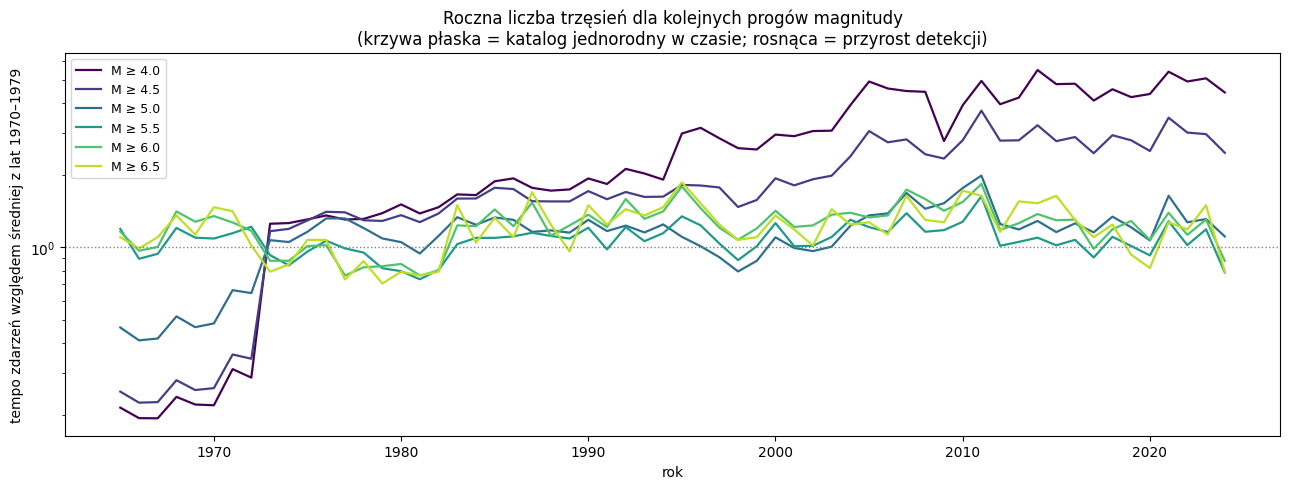

In [9]:
# WYKRES 1 (jedno kodowanie: wysokosc krzywej) - roczne tempo dla kolejnych
# progow, kazda krzywa znormalizowana do wlasnej sredniej z lat 1970-1979. Os Y
# logarytmiczna, bo progi roznia sie o dwa rzedy wielkosci. Krzywa plaska =
# katalog jednorodny; rosnaca = przyrost detekcji.
import matplotlib.pyplot as plt

KOLORY = plt.cm.viridis(np.linspace(0, 0.9, len(PROGI)))
fig, ax = plt.subplots(figsize=(13, 5))
for m, kol in zip(PROGI, KOLORY):
    baza = N[m][(LATA >= 1970) & (LATA < 1980)].mean()
    ax.plot(LATA, N[m] / baza, color=kol, lw=1.6, label=f"M ≥ {m}")
ax.axhline(1, color="gray", ls=":", lw=1)
ax.set_yscale("log")
ax.set_xlabel("rok")
ax.set_ylabel("tempo zdarzeń względem średniej z lat 1970–1979")
ax.set_title("Roczna liczba trzęsień dla kolejnych progów magnitudy\n"
             "(krzywa płaska = katalog jednorodny w czasie; rosnąca = przyrost detekcji)")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/oscylacje_1_tempo_progi.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/oscylacje_1_tempo_progi.png")

Zapisano ../results/oscylacje_2_kompletnosc.png


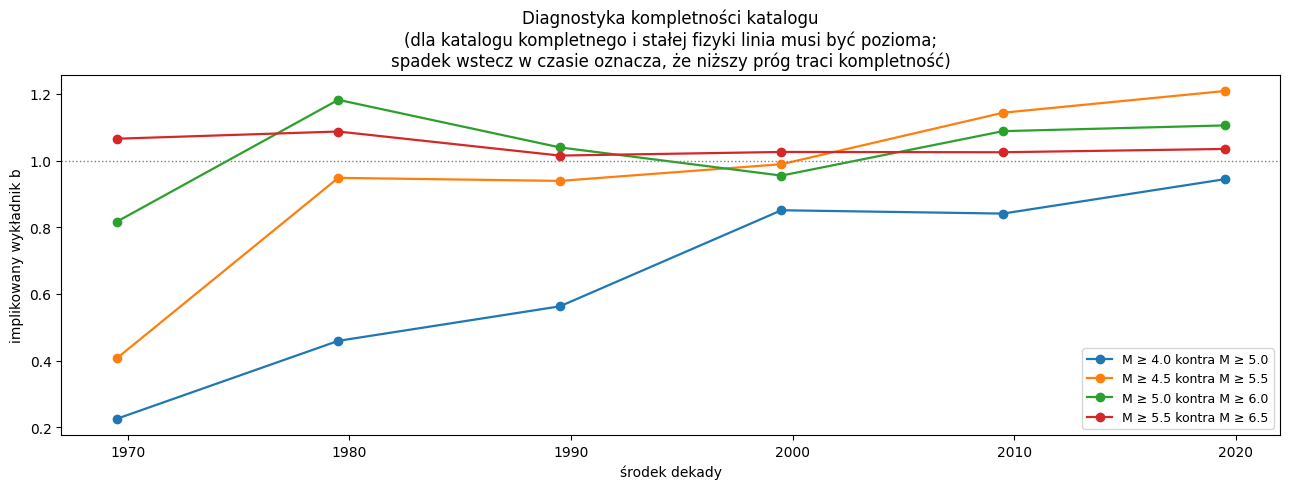

In [10]:
# WYKRES 2 (jedno kodowanie: wysokosc krzywej) - DIAGNOSTYKA KOMPLETNOSCI.
# Implikowany wykladnik b w oknach 10-letnich. Linia plaska = kompletnosc bez
# zmian; linia opadajaca wstecz w czasie = male zdarzenia gina z katalogu.
fig, ax = plt.subplots(figsize=(13, 5))
srodki = [(a + b) / 2 for a, b in dekady]
for i, (m1, m2) in enumerate(PARY):
    ax.plot(srodki, tab[i], "o-", lw=1.6, label=f"M ≥ {m1} kontra M ≥ {m2}")
ax.axhline(1.0, color="gray", ls=":", lw=1)
ax.set_xlabel("środek dekady")
ax.set_ylabel("implikowany wykładnik b")
ax.set_title("Diagnostyka kompletności katalogu\n"
             "(dla katalogu kompletnego i stałej fizyki linia musi być pozioma;\n"
             "spadek wstecz w czasie oznacza, że niższy próg traci kompletność)")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/oscylacje_2_kompletnosc.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/oscylacje_2_kompletnosc.png")

Zapisano ../results/oscylacje_3_reszty.png


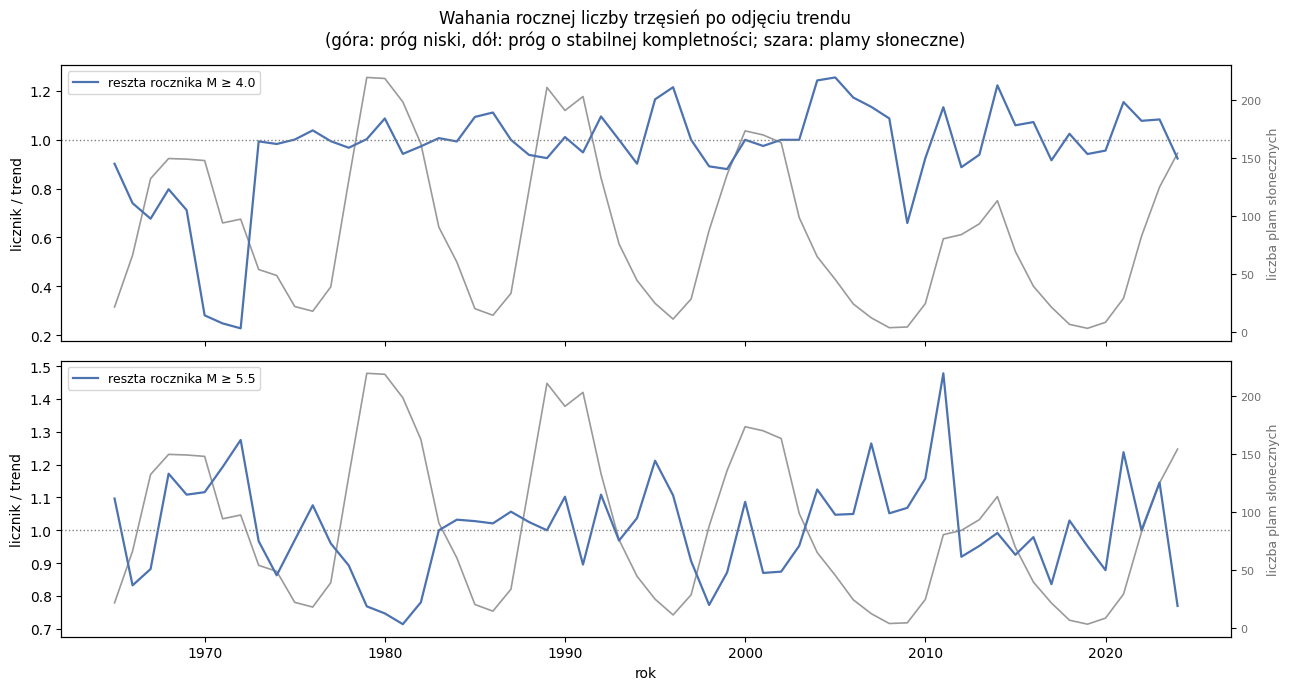

In [11]:
# WYKRES 3 (jedno kodowanie: wysokosc krzywej) - SAME OSCYLACJE, czyli reszta
# po odjeciu trendu, dla progu niskiego i dla progu glownego. Metoda
# odtrendowania: mediana 21-letnia (najmniej obciazona wzgledem cyklu
# ~11-letniego). Na osi pomocniczej liczba plam - zeby dalo sie ocenic okiem, o
# czym mowi test korelacji z komorki 6.
fig, osie = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax, m in zip(osie, [PROGI[0], PROG_GLOWNY]):
    R = RESZTY[(m, "mediana21")]
    ax.plot(LATA, R, color="#4C72B0", lw=1.6, label=f"reszta rocznika M ≥ {m}")
    ax.axhline(1, color="gray", ls=":", lw=1)
    ax.set_ylabel("licznik / trend")
    ax.legend(fontsize=9, loc="upper left")
    ax2 = ax.twinx()
    ax2.plot(LATA, PLAMY, color="#9A9A9A", lw=1.2)
    ax2.set_ylabel("liczba plam słonecznych", color="#6E6E6E", fontsize=9)
    ax2.tick_params(axis="y", labelcolor="#6E6E6E", labelsize=8)
    ax2.set_zorder(0)
    ax.set_zorder(1)
    ax.patch.set_visible(False)
osie[-1].set_xlabel("rok")
fig.suptitle("Wahania rocznej liczby trzęsień po odjęciu trendu\n"
             "(góra: próg niski, dół: próg o stabilnej kompletności; szara: plamy słoneczne)")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/oscylacje_3_reszty.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/oscylacje_3_reszty.png")

Zapisano ../results/oscylacje_4_nadwyzka_poissona.png


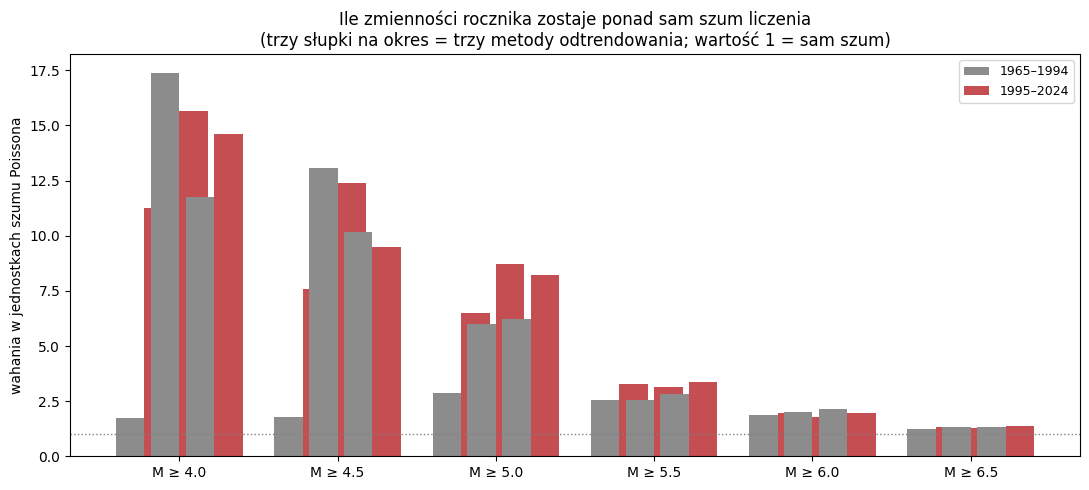

In [12]:
# WYKRES 4 (jedno kodowanie: wysokosc slupka) - NADWYZKA NAD POISSONEM, prog po
# progu, osobno dla obu polowek okresu. To jest wykres, ktory wprost odpowiada na
# hipoteze: "wahania sa wszedzie, tylko wczesniej zagluszone".
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(PROGI))
for k, (nazwa, przes) in enumerate([("izotoniczna", -0.22), ("wielomian3", 0.0),
                                    ("mediana21", 0.22)]):
    for okr, kol, etyk, alfa in [(wcz, "#8C8C8C", f"{LATA[0]}–{ROK_PODZIALU - 1}", 1.0),
                                 (poz, "#C44E52", f"{ROK_PODZIALU}–{LATA[-1]}", 1.0)]:
        v = []
        for m in PROGI:
            R = RESZTY[(m, nazwa)]
            ok = ~np.isnan(R[okr])
            v.append(np.nanstd(R[okr]) / np.mean(1 / np.sqrt(np.maximum(N[m][okr][ok], 1))))
        ax.bar(x + przes + (0.09 if okr is poz else -0.09), v, 0.18, color=kol, alpha=alfa,
               label=etyk if k == 1 else None)
ax.axhline(1, color="gray", ls=":", lw=1)
ax.set_xticks(x)
ax.set_xticklabels([f"M ≥ {m}" for m in PROGI])
ax.set_ylabel("wahania w jednostkach szumu Poissona")
ax.set_title("Ile zmienności rocznika zostaje ponad sam szum liczenia\n"
             "(trzy słupki na okres = trzy metody odtrendowania; wartość 1 = sam szum)")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/oscylacje_4_nadwyzka_poissona.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/oscylacje_4_nadwyzka_poissona.png")

Zapisano ../results/oscylacje_5_skan_po_lagu.png

UWAGA DO ODCZYTU TEGO WYKRESU: przy drajwerze quasi-okresowym o okresie
~11 lat krzywa lagu MUSI zmieniac znak co okolo 5,5 roku. Zmiana znaku nie
jest wiec zadnym potwierdzeniem - jest wlasnoscia okresowosci. Czytelne
jest wylacznie to, czy krzywa wychodzi poza pasmo i w ktorym miejscu.


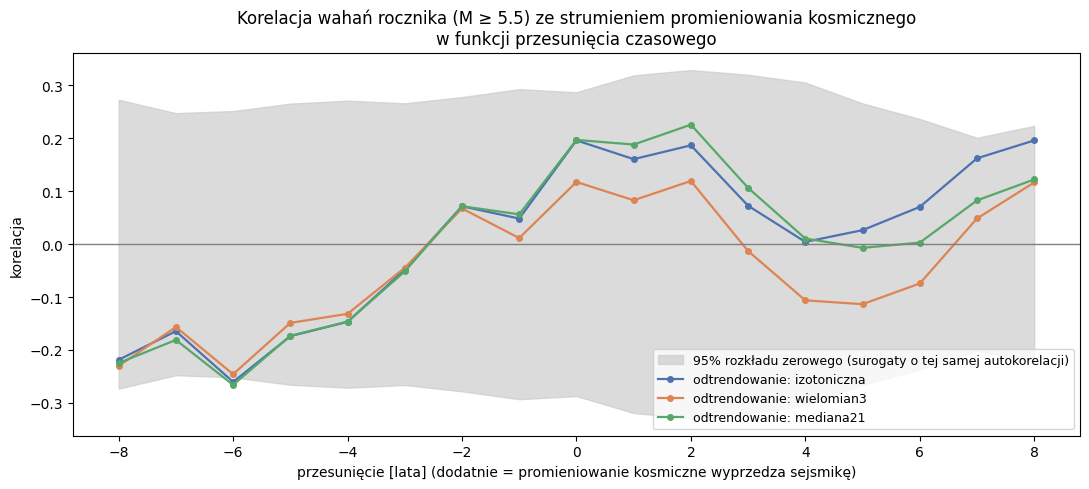

In [13]:
# WYKRES 5 (jedno kodowanie: wysokosc krzywej) - SKAN PO LAGU z pasmem rozkladu
# zerowego. Pasmo liczone z randomizacji faz, czyli z surogatow o tej samej
# autokorelacji co reszta. Bez tego pasma sama krzywa lagu jest nieczytelna, bo
# nie wiadomo, ktore odchylenie jest duze.
R = RESZTY[(PROG_GLOWNY, "mediana21")]
ok = ~np.isnan(R) & ~np.isnan(CR)
pasmo = []
for lag in LAGI:
    if lag < 0:
        a, b = R[-lag:], CR[:lag]
    elif lag > 0:
        a, b = R[:-lag], CR[lag:]
    else:
        a, b = R, CR
    o = ~np.isnan(a) & ~np.isnan(b)
    null = [np.corrcoef(losuj_faza(a[o], rng), b[o])[0, 1] for _ in range(1000)]
    pasmo.append(np.percentile(np.abs(null), 95))
fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(LAGI, -np.array(pasmo), np.array(pasmo), color="#CCCCCC", alpha=0.7,
                label="95% rozkładu zerowego (surogaty o tej samej autokorelacji)")
for nazwa, kol in zip(METODY, ["#4C72B0", "#DD8452", "#55A868"]):
    pod = lag_tab[(lag_tab.driver == "CR Moskwa") & (lag_tab.metoda == nazwa)]
    ax.plot(pod["lag"], pod["r"], "o-", color=kol, lw=1.6, ms=4, label=f"odtrendowanie: {nazwa}")
ax.axhline(0, color="gray", lw=1)
ax.set_xlabel("przesunięcie [lata] (dodatnie = promieniowanie kosmiczne wyprzedza sejsmikę)")
ax.set_ylabel("korelacja")
ax.set_title(f"Korelacja wahań rocznika (M ≥ {PROG_GLOWNY}) ze strumieniem promieniowania "
             f"kosmicznego\nw funkcji przesunięcia czasowego")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/oscylacje_5_skan_po_lagu.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/oscylacje_5_skan_po_lagu.png")
print()
print("UWAGA DO ODCZYTU TEGO WYKRESU: przy drajwerze quasi-okresowym o okresie")
print("~11 lat krzywa lagu MUSI zmieniac znak co okolo 5,5 roku. Zmiana znaku nie")
print("jest wiec zadnym potwierdzeniem - jest wlasnoscia okresowosci. Czytelne")
print("jest wylacznie to, czy krzywa wychodzi poza pasmo i w ktorym miejscu.")

In [14]:
# PODSUMOWANIE, czytane wedlug regul z komorki 0, ustalonych przed uruchomieniem.
print("=" * 78)
print("OSCYLACJE ROCZNIKA - PODSUMOWANIE")
print("=" * 78)
print()
print(f"Prog glowny wybrany diagnostyka kompletnosci: M >= {PROG_GLOWNY}")
print()

# --- pytanie 1: sejsmiczne czy detekcyjne ---
niski = PROGI[0]
kor = []
for nazwa in METODY:
    a = RESZTY[(niski, nazwa)]
    b = RESZTY[(PROG_GLOWNY, nazwa)]
    ow = wcz & ~np.isnan(a) & ~np.isnan(b)
    op = poz & ~np.isnan(a) & ~np.isnan(b)
    kor.append((np.corrcoef(a[ow], b[ow])[0, 1], np.corrcoef(a[op], b[op])[0, 1]))
kw, kp = np.mean([k[0] for k in kor]), np.mean([k[1] for k in kor])
print(f"1. CZY OSCYLACJE NISKIEGO PROGU SA SEJSMICZNE")
print(f"   korelacja reszty M>={niski} z reszta M>={PROG_GLOWNY} (srednia po metodach):")
print(f"     {LATA[0]}-{ROK_PODZIALU - 1}: {kw:+.2f}      {ROK_PODZIALU}-{LATA[-1]}: {kp:+.2f}")
if kw > 0.7 and kp > 0.7:
    print("   ODCZYT A: oscylacje sa sejsmiczne przez caly okres.")
elif kp - kw > 0.15 and kp > 0.35:
    print("   ODCZYT B: katalog niskiego progu zaczyna niesc sygnal sejsmiczny")
    print("   dopiero w drugiej polowie okresu. To jest hipoteza Macka o erze 2008")
    print("   jako najmniej skazonej - potwierdzona co do kierunku. Ale poziom")
    print("   korelacji mowi tez, ile z tych wahan NIE jest sejsmiczne.")
else:
    print("   ODCZYT C: oscylacje niskiego progu sa wlasnoscia katalogu, nie Ziemi.")
print()

# --- pytanie 2: cykl sloneczny ---
# DIAGNOSTYKA DODANA PO PIERWSZYM URUCHOMIENIU: raportujemy OBA drivery obok
# siebie. Powod jest merytoryczny, nie kosmetyczny. Teza artykulu mowi o
# PROMIENIOWANIU KOSMICZNYM, a nie o plamach slonecznych. Jesli mechanizm jest
# rzeczywiscie kosmiczny, to korelacja ze strumieniem CR musi byc CO NAJMNIEJ
# tak silna jak korelacja z plamami - bo plamy sa tylko posrednim wskaznikiem
# tego samego cyklu. Korelacja silniejsza z plamami niz z CR jest argumentem
# PRZECIW mechanizmowi kosmicznemu. To jest diagnostyka, a nie nowa regula
# odczytu - regula (progi p) zostaje ta z komorki 0.
g = wyniki[wyniki.glowny & (wyniki.driver == "CR Moskwa")]
p_min = g["p_fazy"].min()
p_kara = min(1.0, p_min * len(PROGI))
zgodne = (g["r"] < 0).all() or (g["r"] > 0).all()
print("2. CZY WAHANIA ROCZNIKA KORELUJA Z PROMIENIOWANIEM KOSMICZNYM")
print("   porownanie drajwerow (prog glowny, lag 0):")
for dn in ["plamy", "CR Moskwa"]:
    gd = wyniki[wyniki.glowny & (wyniki.driver == dn)]
    print(f"     {dn:>10}: |r| = {', '.join(f'{abs(v):.3f}' for v in gd['r'])}, "
          f"min p (fazy) = {gd['p_fazy'].min():.4f}")
r_plamy = np.mean(np.abs(wyniki[wyniki.glowny & (wyniki.driver == 'plamy')]["r"]))
r_cr = np.mean(np.abs(wyniki[wyniki.glowny & (wyniki.driver == 'CR Moskwa')]["r"]))
if r_plamy > r_cr:
    print(f"     -> korelacja z plamami ({r_plamy:.3f}) jest SILNIEJSZA niz ze")
    print(f"        strumieniem CR ({r_cr:.3f}). Dla mechanizmu kosmicznego powinno")
    print(f"        byc odwrotnie: plamy sa tylko posrednim wskaznikiem cyklu.")
    print(f"        To jest argument przeciw odczytowi kosmicznemu tej korelacji.")
else:
    print(f"     -> korelacja ze strumieniem CR ({r_cr:.3f}) jest co najmniej tak")
    print(f"        silna jak z plamami ({r_plamy:.3f}), czyli zgodna z mechanizmem")
    print(f"        kosmicznym co do struktury.")
print()

print(f"   prog glowny, trzy metody odtrendowania: r = "
      f"{', '.join(f'{v:+.3f}' for v in g['r'])}")
print(f"   znak {'ZGODNY' if zgodne else 'NIEZGODNY'} miedzy metodami")
print(f"   najmniejsze p (randomizacja faz) = {p_min:.4f}; po karze za {len(PROGI)} progow: {p_kara:.3f}")
if p_kara < 0.01 and zgodne:
    print("   ODCZYT: sygnal wart osobnego, potwierdzajacego badania na niezaleznych")
    print("   danych (inny katalog, inna stacja, inny zakres lat).")
elif p_kara < 0.1 and zgodne:
    print("   ODCZYT: PRZESLANKA, NIE WYNIK. Kierunek jest spojny, ale przy 60 latach")
    print("   (5,5 cyklu) i po uczciwej karze za proby to nie wystarcza, zeby mowic o")
    print("   zwiazku. Wymaga niezaleznego zbioru danych.")
else:
    print("   ODCZYT: brak podstaw do mowienia o zwiazku rocznika z cyklem slonecznym.")
print()
print("CZEGO TEN NOTEBOOK NIE ROZSTRZYGA:")
print("  - Test NIE byl slepy: wersja eksploracyjna byla policzona w konsoli przed")
print("    napisaniem notebooka (patrz komorka 0). Kazdy wynik pozytywny jest wiec")
print("    hipoteza do potwierdzenia, a nie pomiarem.")
print("  - 60 lat to 5,5 cyklu slonecznego. Kazda korelacja ~11-letnia jest tu")
print("    mierzona z okolo pieciu niezaleznych probek.")
print("  - Kierunek korelacji nie identyfikuje mechanizmu: cokolwiek innego, co")
print("    chodzi w rytmie cyklu (w tym systematyka opracowania katalogu), da ten")
print("    sam znak.")
print("  - Reszta zalezy od metody odtrendowania. Wniosek wolno wyciagac tylko z")
print("    tego, co wychodzi we wszystkich trzech.")

OSCYLACJE ROCZNIKA - PODSUMOWANIE

Prog glowny wybrany diagnostyka kompletnosci: M >= 5.5

1. CZY OSCYLACJE NISKIEGO PROGU SA SEJSMICZNE
   korelacja reszty M>=4.0 z reszta M>=5.5 (srednia po metodach):
     1965-1994: -0.18      1995-2024: +0.48
   ODCZYT B: katalog niskiego progu zaczyna niesc sygnal sejsmiczny
   dopiero w drugiej polowie okresu. To jest hipoteza Macka o erze 2008
   jako najmniej skazonej - potwierdzona co do kierunku. Ale poziom
   korelacji mowi tez, ile z tych wahan NIE jest sejsmiczne.

2. CZY WAHANIA ROCZNIKA KORELUJA Z PROMIENIOWANIEM KOSMICZNYM
   porownanie drajwerow (prog glowny, lag 0):
          plamy: |r| = 0.237, 0.242, 0.324, min p (fazy) = 0.0246
      CR Moskwa: |r| = 0.196, 0.118, 0.197, min p (fazy) = 0.0934
     -> korelacja z plamami (0.268) jest SILNIEJSZA niz ze
        strumieniem CR (0.170). Dla mechanizmu kosmicznego powinno
        byc odwrotnie: plamy sa tylko posrednim wskaznikiem cyklu.
        To jest argument przeciw odczytowi kosmicz